Big Data And Data Science;

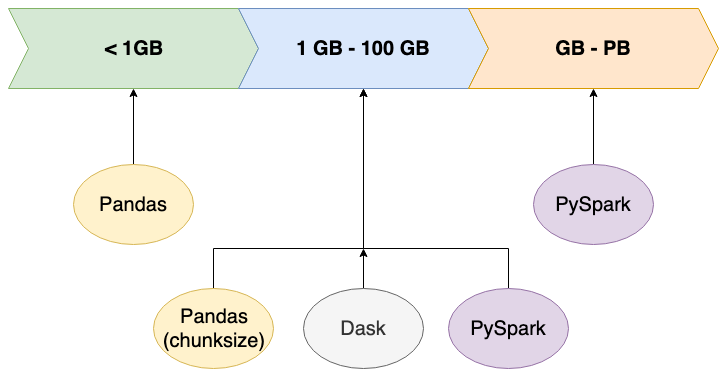

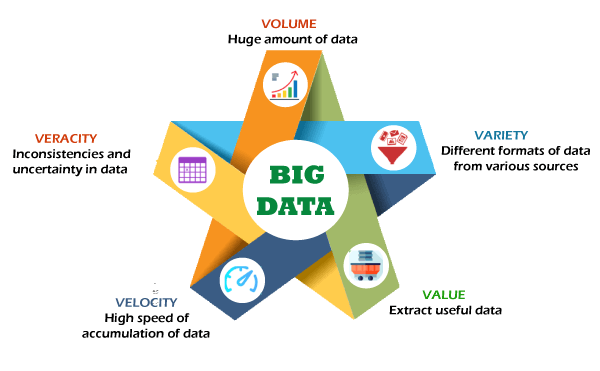

# Required things;

In [1]:
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.8/310.8 MB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - \ done
  Created wheel for pyspark: filename=pyspark-3.4.0-py2.py3-none-any.whl size=311317146 sha256=b895b5b0ec76b5a2a7ce96285297cf924edf8f212b598f72a0ae77cc01492a00
  Stored in directory: /root/.cache/pip/wheels/7b/1b/4b/3363a1d04368e7ff0d408e57ff57966fcdf00583774e761327
Successfully built pyspark


In [2]:
import pyspark

In [3]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Data Reads And Pre-Processing;

In [4]:
Path = "/kaggle/input/fashion-product-images-dataset/fashion-dataset/fashion-dataset/"
print(os.listdir(Path))

['images.csv', 'images', 'styles.csv', 'styles']


In [5]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName(' Deep Learning App').getOrCreate()

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
23/05/16 12:45:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [6]:
spark

In [7]:
df_pyspark = spark.read.option('header','true').csv(Path + "styles.csv", inferSchema=True).limit(5000)

In [8]:
df_pyspark.show()

+-----+------+--------------+-----------+------------+----------+------+----+------+--------------------+
|   id|gender|masterCategory|subCategory| articleType|baseColour|season|year| usage|  productDisplayName|
+-----+------+--------------+-----------+------------+----------+------+----+------+--------------------+
|15970|   Men|       Apparel|    Topwear|      Shirts| Navy Blue|  Fall|2011|Casual|Turtle Check Men ...|
|39386|   Men|       Apparel| Bottomwear|       Jeans|      Blue|Summer|2012|Casual|Peter England Men...|
|59263| Women|   Accessories|    Watches|     Watches|    Silver|Winter|2016|Casual|Titan Women Silve...|
|21379|   Men|       Apparel| Bottomwear| Track Pants|     Black|  Fall|2011|Casual|Manchester United...|
|53759|   Men|       Apparel|    Topwear|     Tshirts|      Grey|Summer|2012|Casual|Puma Men Grey T-s...|
| 1855|   Men|       Apparel|    Topwear|     Tshirts|      Grey|Summer|2011|Casual|Inkfruit Mens Cha...|
|30805|   Men|       Apparel|    Topwear|     

In [9]:
df_pyspark.printSchema()

root
 |-- id: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- masterCategory: string (nullable = true)
 |-- subCategory: string (nullable = true)
 |-- articleType: string (nullable = true)
 |-- baseColour: string (nullable = true)
 |-- season: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- usage: string (nullable = true)
 |-- productDisplayName: string (nullable = true)



In [10]:
df_pyspark.head(10)

[Row(id=15970, gender='Men', masterCategory='Apparel', subCategory='Topwear', articleType='Shirts', baseColour='Navy Blue', season='Fall', year=2011, usage='Casual', productDisplayName='Turtle Check Men Navy Blue Shirt'),
 Row(id=39386, gender='Men', masterCategory='Apparel', subCategory='Bottomwear', articleType='Jeans', baseColour='Blue', season='Summer', year=2012, usage='Casual', productDisplayName='Peter England Men Party Blue Jeans'),
 Row(id=59263, gender='Women', masterCategory='Accessories', subCategory='Watches', articleType='Watches', baseColour='Silver', season='Winter', year=2016, usage='Casual', productDisplayName='Titan Women Silver Watch'),
 Row(id=21379, gender='Men', masterCategory='Apparel', subCategory='Bottomwear', articleType='Track Pants', baseColour='Black', season='Fall', year=2011, usage='Casual', productDisplayName='Manchester United Men Solid Black Track Pants'),
 Row(id=53759, gender='Men', masterCategory='Apparel', subCategory='Topwear', articleType='Tshir

In [11]:
df_pyspark.select(['id','gender']).show()

+-----+------+
|   id|gender|
+-----+------+
|15970|   Men|
|39386|   Men|
|59263| Women|
|21379|   Men|
|53759|   Men|
| 1855|   Men|
|30805|   Men|
|26960| Women|
|29114|   Men|
|30039|   Men|
| 9204|   Men|
|48123| Women|
|18653|   Men|
|47957| Women|
|46885|  Boys|
|12369|   Men|
|29928|   Men|
|42419| Girls|
|51832| Women|
|47359| Women|
+-----+------+
only showing top 20 rows



In [12]:
from pyspark.sql.functions import concat, col, lit

df_pyspark = df_pyspark.withColumn('image',concat(df_pyspark['id'],lit('.jpg')))

In [13]:
df_pyspark.show()

+-----+------+--------------+-----------+------------+----------+------+----+------+--------------------+---------+
|   id|gender|masterCategory|subCategory| articleType|baseColour|season|year| usage|  productDisplayName|    image|
+-----+------+--------------+-----------+------------+----------+------+----+------+--------------------+---------+
|15970|   Men|       Apparel|    Topwear|      Shirts| Navy Blue|  Fall|2011|Casual|Turtle Check Men ...|15970.jpg|
|39386|   Men|       Apparel| Bottomwear|       Jeans|      Blue|Summer|2012|Casual|Peter England Men...|39386.jpg|
|59263| Women|   Accessories|    Watches|     Watches|    Silver|Winter|2016|Casual|Titan Women Silve...|59263.jpg|
|21379|   Men|       Apparel| Bottomwear| Track Pants|     Black|  Fall|2011|Casual|Manchester United...|21379.jpg|
|53759|   Men|       Apparel|    Topwear|     Tshirts|      Grey|Summer|2012|Casual|Puma Men Grey T-s...|53759.jpg|
| 1855|   Men|       Apparel|    Topwear|     Tshirts|      Grey|Summer|

In [14]:
spark.conf.set("spark.sql.execution.arrow.enabled", "true")
df = df_pyspark.toPandas()

23/05/16 12:45:52 WARN SQLConf: The SQL config 'spark.sql.execution.arrow.enabled' has been deprecated in Spark v3.0 and may be removed in the future. Use 'spark.sql.execution.arrow.pyspark.enabled' instead of it.


Data Visualizations & Insights;

In [15]:
import cv2
def plot_figures(figures, nrows = 1, ncols=1,figsize=(14, 14)):

    fig, axeslist = plt.subplots(ncols=ncols, nrows=nrows,figsize=figsize)
    for ind,title in enumerate(figures):
        axeslist.ravel()[ind].imshow(cv2.cvtColor(figures[title], cv2.COLOR_BGR2RGB))
        axeslist.ravel()[ind].set_title(title)
        axeslist.ravel()[ind].set_axis_off()
    plt.tight_layout()
    
def img_path(img):
    return Path+"/images/"+img

def load_image(img, resized_fac = 0.1):
    img     = cv2.imread(img_path(img))
    w, h, _ = img.shape
    resized = cv2.resize(img, (int(h*resized_fac), int(w*resized_fac)), interpolation = cv2.INTER_AREA)
    return resized

<AxesSubplot: >

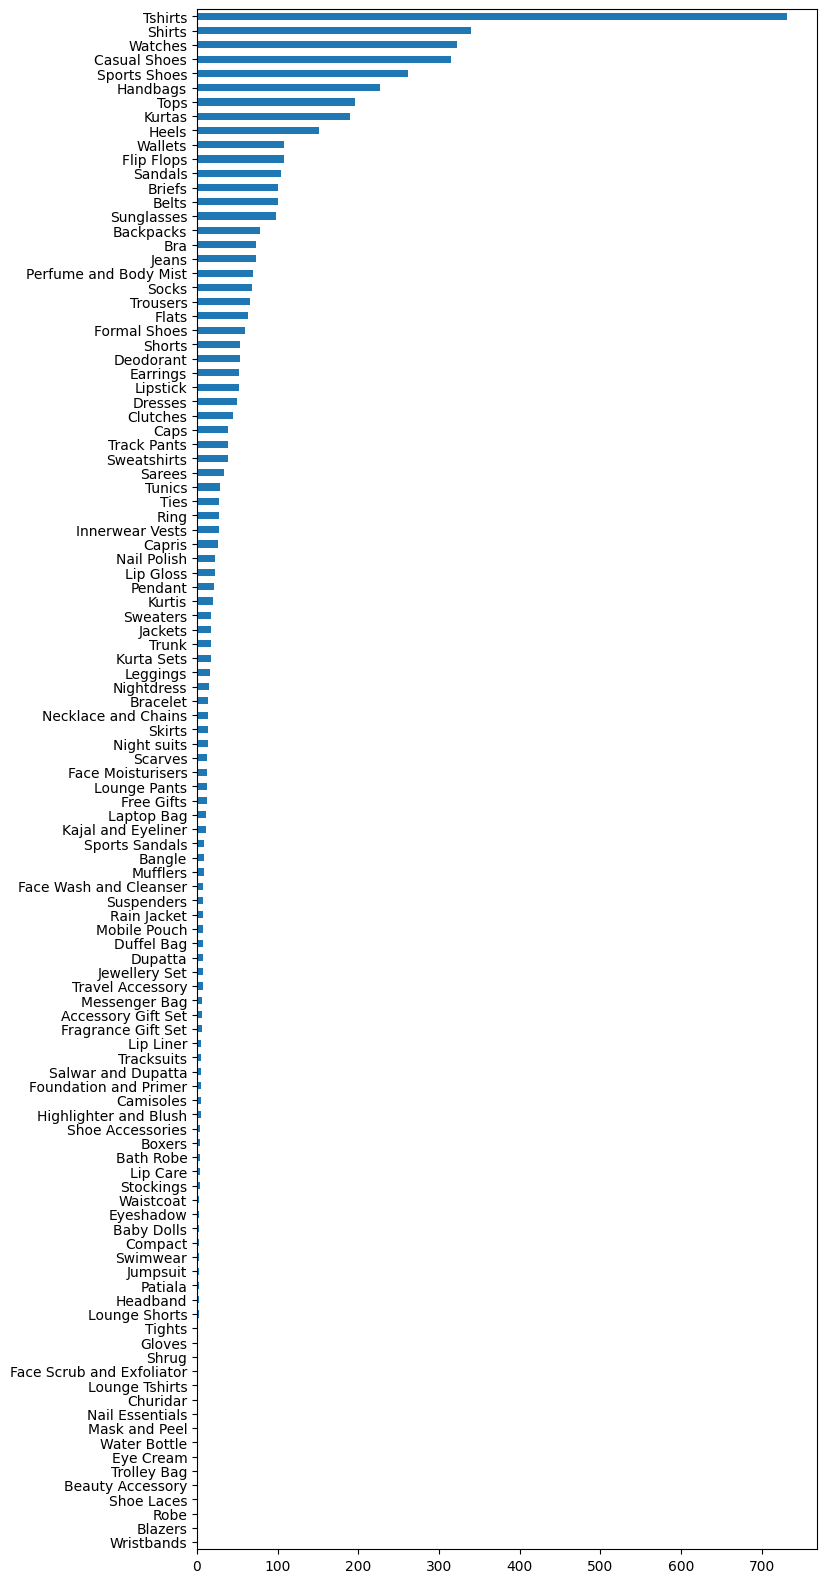

In [16]:
plt.figure(figsize=(8,20))
df.articleType.value_counts().sort_values().plot(kind='barh')

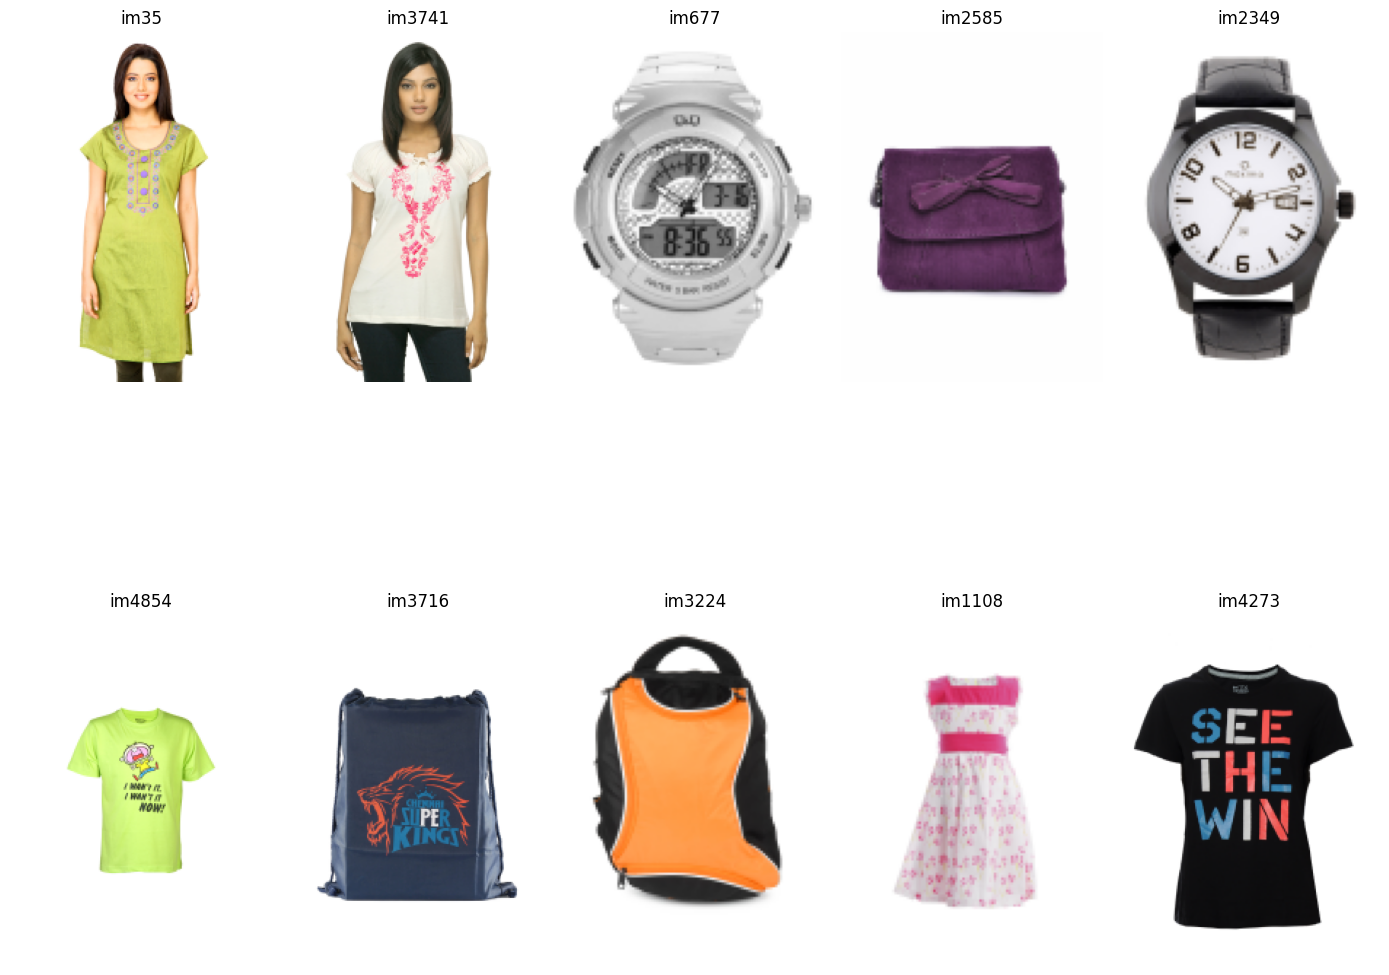

In [17]:
figures = {'im'+str(i): load_image(row.image) for i, row in df.sample(10).iterrows()}
plot_figures(figures, 2, 5)

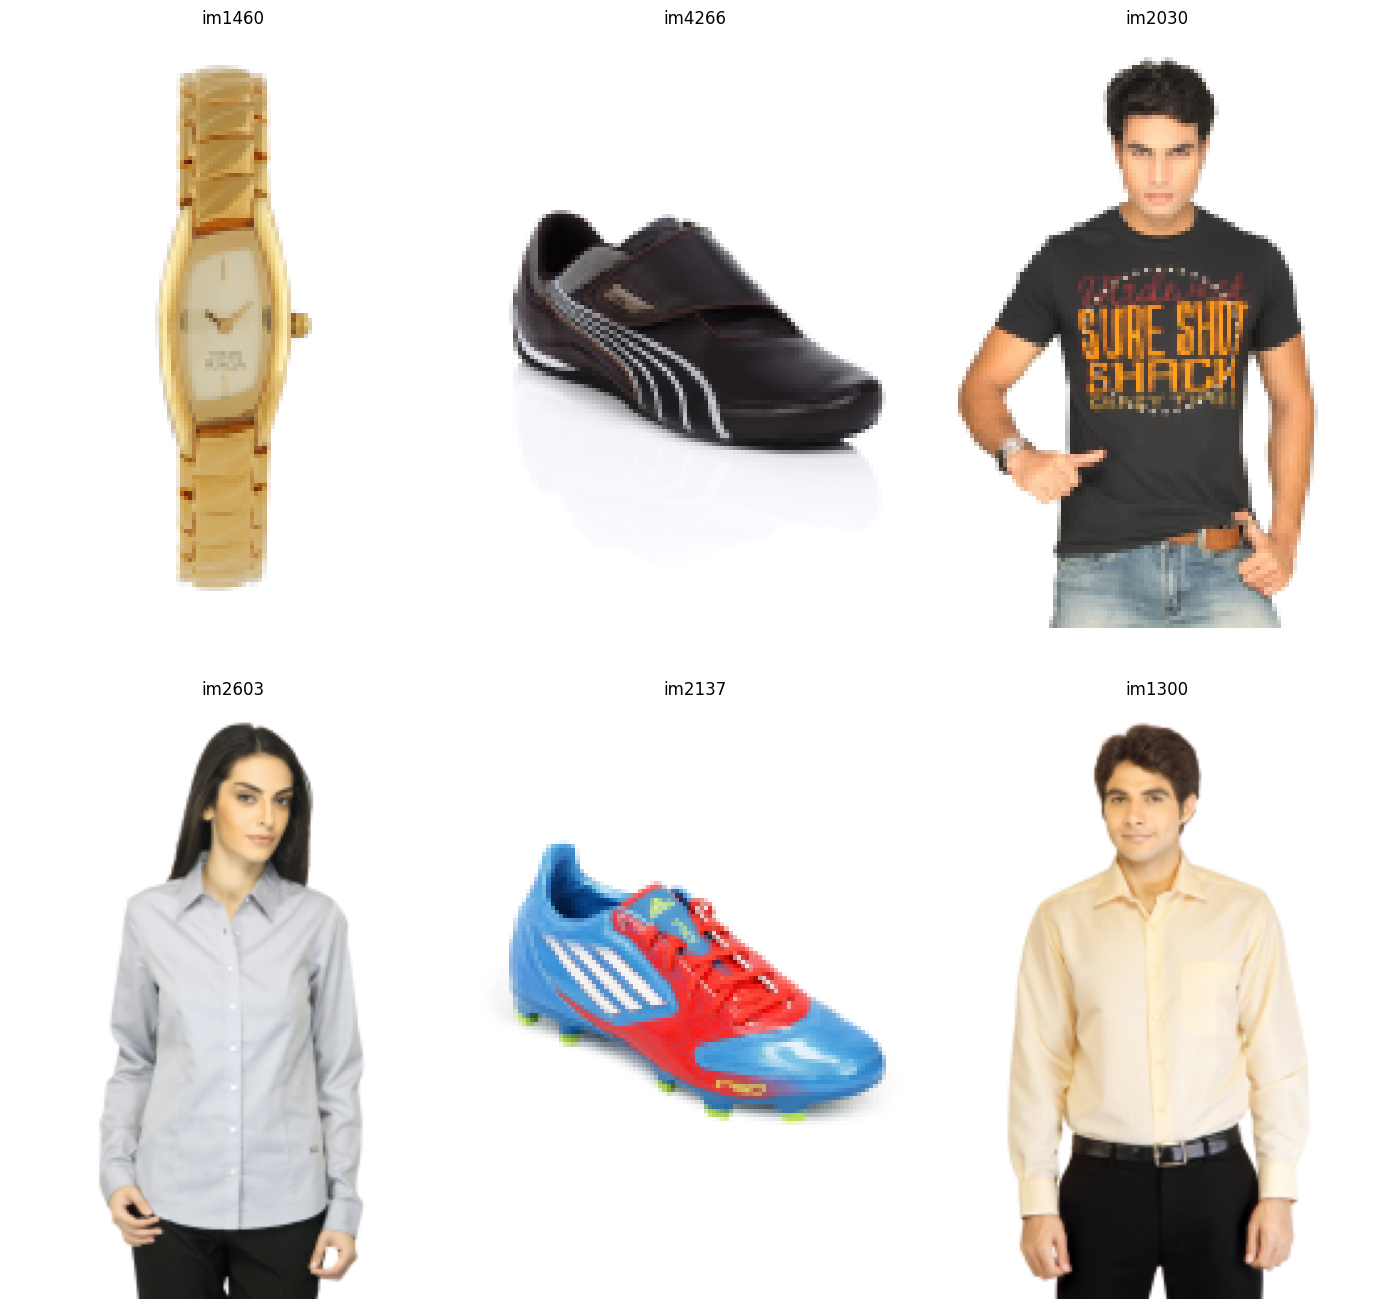

In [18]:
figures = {'im'+str(i): load_image(row.image) for i, row in df.sample(6).iterrows()}
plot_figures(figures, 2, 3)

# Deep Learning Model Implemantions;

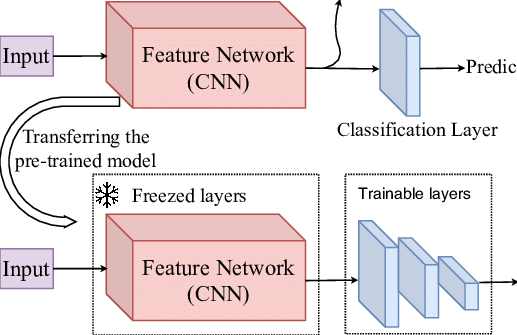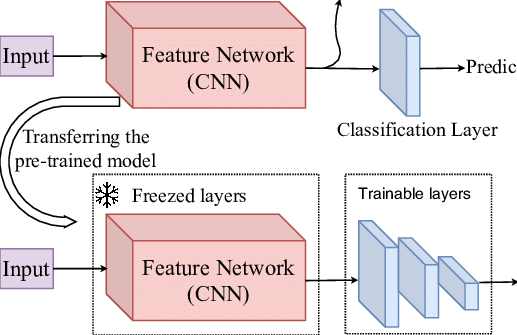

In [19]:
import tensorflow as tf
import keras
from keras import Model

from tensorflow.keras.applications.resnet50 import ResNet50
from keras.preprocessing import image

from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from keras.layers import GlobalMaxPooling2D

tf.__version__

'2.11.0'

In [20]:
img_width, img_height, _ = 256, 256, 3
base_model = ResNet50(weights='imagenet', 
                      include_top=False, 
                      input_shape = (img_width, img_height, 3))
base_model.trainable = False

model = keras.Sequential([
    base_model,
    GlobalMaxPooling2D()
])
model.summary()

94765736/94765736 [==============================] - 1s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 8, 8, 2048)        23587712  
                                                                 
 global_max_pooling2d (Globa  (None, 2048)             0         
 lMaxPooling2D)                                                  
                                                                 
Total params: 23,587,712
Trainable params: 0
Non-trainable params: 23,587,712
_________________________________________________________________


In [21]:
def get_embedding(model, img_name):
    img = image.load_img(img_path(img_name), target_size=(img_width, img_height))
    x   = image.img_to_array(img)
    x   = np.expand_dims(x, axis=0)
    x   = preprocess_input(x)
    return model.predict(x).reshape(-1)

(240, 180, 3)


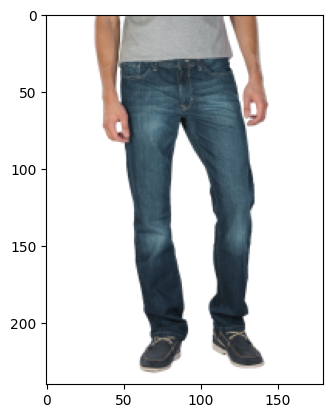

In [22]:
img_array = load_image(df.iloc[1].image)
plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
print(img_array.shape)

(144, 108, 3)


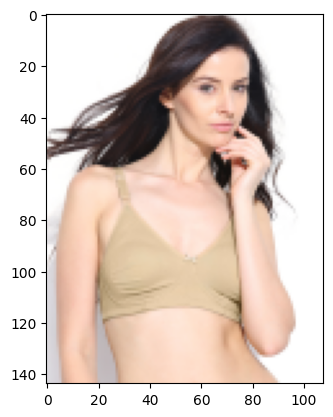

In [23]:
img_array = load_image(df.iloc[18].image)
plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
print(img_array.shape)

(240, 180, 3)


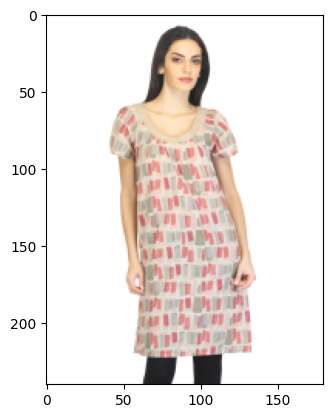

In [24]:
img_array = load_image(df.iloc[43].image)
plt.imshow(cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB))
print(img_array.shape)

In [25]:
df

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011,Casual,Turtle Check Men Navy Blue Shirt,15970.jpg
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012,Casual,Peter England Men Party Blue Jeans,39386.jpg
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016,Casual,Titan Women Silver Watch,59263.jpg
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011,Casual,Manchester United Men Solid Black Track Pants,21379.jpg
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012,Casual,Puma Men Grey T-shirt,53759.jpg
...,...,...,...,...,...,...,...,...,...,...,...
4995,44573,Men,Footwear,Sandal,Sandals,Brown,Summer,2012,Casual,Coolers Men Brown Sandals,44573.jpg
4996,37081,Women,Accessories,Bags,Handbags,Brown,Summer,2012,Casual,Lino Perros Women Brown Handbag,37081.jpg
4997,57958,Women,Apparel,Saree,Sarees,Green,Summer,2012,Ethnic,Prafful Green Printed Sari,57958.jpg
4998,5654,Men,Footwear,Shoes,Sports Shoes,White,Summer,2011,Sports,Reebok Men's Winning Stride White Shoe,5654.jpg


In [26]:
#%%time
#df_sample      = df
#map_embeddings = df_sample['image'].apply(lambda img: get_embedding(model, img))
#df_embs        = map_embeddings.apply(pd.Series)

#print(df_embs.shape)
#df_embs.head(50)

In [27]:
'''

from sklearn.metrics.pairwise import pairwise_distances
cosine_sim = 1-pairwise_distances(df_embs, metric='cosine')
cosine_sim[:4, :4]

'''

"\n\nfrom sklearn.metrics.pairwise import pairwise_distances\ncosine_sim = 1-pairwise_distances(df_embs, metric='cosine')\ncosine_sim[:4, :4]\n\n"

In [28]:
'''
indices = pd.Series(range(len(df)), index=df.index)
indices
def get_recommender(idx, df, top_n = 50):
    sim_idx    = indices[idx]
    sim_scores = list(enumerate(cosine_sim[sim_idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]
    idx_rec    = [i[0] for i in sim_scores]
    idx_sim    = [i[1] for i in sim_scores]
    
    return indices.iloc[idx_rec].index, idx_sim

get_recommender(1999, df, top_n = 50)

'''

'\nindices = pd.Series(range(len(df)), index=df.index)\nindices\ndef get_recommender(idx, df, top_n = 50):\n    sim_idx    = indices[idx]\n    sim_scores = list(enumerate(cosine_sim[sim_idx]))\n    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)\n    sim_scores = sim_scores[1:top_n+1]\n    idx_rec    = [i[0] for i in sim_scores]\n    idx_sim    = [i[1] for i in sim_scores]\n    \n    return indices.iloc[idx_rec].index, idx_sim\n\nget_recommender(1999, df, top_n = 50)\n\n'

In [29]:
'''
idx_ref = 100
idx_rec, idx_sim = get_recommender(idx_ref, df, top_n = 8)
plt.imshow(cv2.cvtColor(load_image(df.iloc[idx_ref].image), cv2.COLOR_BGR2RGB))
figures = {'im'+str(i): load_image(row.image) for i, row in df.loc[idx_rec].iterrows()}
plot_figures(figures, 2, 4)

'''

"\nidx_ref = 100\nidx_rec, idx_sim = get_recommender(idx_ref, df, top_n = 8)\nplt.imshow(cv2.cvtColor(load_image(df.iloc[idx_ref].image), cv2.COLOR_BGR2RGB))\nfigures = {'im'+str(i): load_image(row.image) for i, row in df.loc[idx_rec].iterrows()}\nplot_figures(figures, 2, 4)\n\n"

In [30]:
#